# Notebook 05 — Geometry Optimization

**MOLEKUL | Phase 5**

---

The geometry of a molecule at equilibrium is the structure that minimises the total energy
on the **Born-Oppenheimer potential energy surface** (PES). Finding this structure is called
**geometry optimization**.

**What you will learn:**
1. The Born-Oppenheimer approximation and the concept of the PES.
2. Energy gradients (forces): analytical vs. numerical.
3. The BFGS quasi-Newton optimizer.
4. Convergence criteria: gradient norm and energy change.
5. Reading the optimization trajectory.
6. The effect of basis set on equilibrium geometry.

## 1. The Born-Oppenheimer potential energy surface

The Born-Oppenheimer (BO) approximation separates nuclear and electronic motion:
because electrons are ~2000× lighter than nuclei, they adjust instantaneously
to each nuclear configuration $\mathbf{R}$.

The **PES** is the function $E(\mathbf{R})$: the total energy as a function of all
$3N_{\text{atoms}}$ nuclear coordinates. For a $N$-atom molecule this is a
$3N - 6$ dimensional surface (3 translational + 3 rotational DOF removed).

The **equilibrium geometry** is a local minimum of the PES:
$$\nabla_{\mathbf{R}} E = \mathbf{0}, \quad \mathbf{H}_{\text{Hessian}} \succ 0$$

The gradient $\partial E / \partial R_{A\alpha}$ is related to the force on atom $A$
along Cartesian direction $\alpha$: $F_{A\alpha} = -\partial E / \partial R_{A\alpha}$.

In [1]:
# --- Make the MOLEKUL package importable -------------------------------
# Best practice: install once from the repo root with
#     pip install -e ".[notebooks]"
# The fallback below locates the in-repo src/ automatically, so the
# notebook also runs from a fresh clone that has not been installed yet,
# regardless of which directory Jupyter was started from.
try:
    import molekul  # noqa: F401
except ModuleNotFoundError:
    import sys, pathlib
    for _p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_p / "src" / "molekul").is_dir():
            sys.path.insert(0, str(_p / "src"))
            break
    import molekul  # noqa: F401
# -----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from molekul.atoms import Atom
from molekul.molecule import Molecule
from molekul.basis_sto3g import STO3G
from molekul.basis_631gstar import G631Star
from molekul.rhf import rhf_scf
from molekul.optimizer import optimize_geometry
from molekul.grad import numerical_gradient
from molekul.constants import ANGSTROM_TO_BOHR, BOHR_TO_ANGSTROM, HARTREE_TO_KCAL_MOL

print("Imports OK")

Imports OK


## 2. Scanning the PES of H₂

For diatomic molecules the PES is just one-dimensional: $E(R)$.
We can scan it by computing the RHF energy at each bond length.

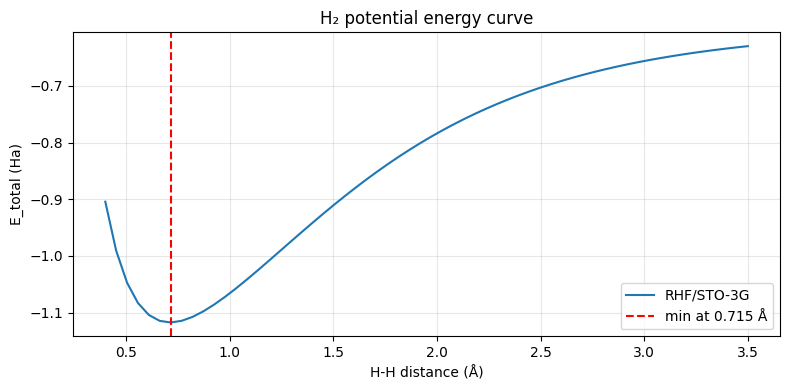

PES minimum at R = 0.7153 Å  (exp. 0.741 Å)


In [2]:
basis = STO3G
bond_lengths = np.linspace(0.4, 3.5, 60)  # Angstrom

energies = []
for r in bond_lengths:
    mol = Molecule(
        atoms=[
            Atom.from_angstrom("H", 0.0, 0.0,  r/2),
            Atom.from_angstrom("H", 0.0, 0.0, -r/2),
        ]
    )
    res = rhf_scf(mol, basis)
    energies.append(res.energy_total)

energies = np.array(energies)
i_min = np.argmin(energies)

plt.figure(figsize=(8, 4))
plt.plot(bond_lengths, energies, label="RHF/STO-3G")
plt.axvline(bond_lengths[i_min], ls="--", color="red",
            label=f"min at {bond_lengths[i_min]:.3f} Å")
plt.xlabel("H-H distance (Å)")
plt.ylabel("E_total (Ha)")
plt.title("H₂ potential energy curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PES minimum at R = {bond_lengths[i_min]:.4f} Å  (exp. 0.741 Å)")

## 3. The energy gradient

For a general molecule, scanning the PES is infeasible — with $N$ atoms we would need
to sample a $3N$-dimensional space. Instead, we use the **gradient** to guide the optimizer.

MOLEKUL computes the gradient numerically by **central finite differences**:
$$\frac{\partial E}{\partial R_{A\alpha}} \approx
\frac{E(\mathbf{R} + h\,\hat{e}_{A\alpha}) - E(\mathbf{R} - h\,\hat{e}_{A\alpha})}{2h}$$

This requires $2 \times 3N$ energy evaluations per gradient call — expensive but exact
to $\mathcal{O}(h^2)$. Phase 18 adds a semi-numerical analytical gradient as an alternative.

In [3]:
# Compute the gradient for H2 at a non-equilibrium geometry
h2 = Molecule(
    atoms=[
        Atom.from_angstrom("H", 0.0, 0.0,  0.50),  # stretched beyond equilibrium
        Atom.from_angstrom("H", 0.0, 0.0, -0.50),
    ]
)

grad = numerical_gradient(h2, STO3G, h=1e-3)  # shape (n_atoms, 3)

print("Gradient (Ha/bohr):")
for i, (atom, g) in enumerate(zip(h2.atoms, grad)):
    print(f"  Atom {i} ({atom.symbol}): gx={g[0]:+.6f}  gy={g[1]:+.6f}  gz={g[2]:+.6f}")
print()
print("The z-components are equal and opposite (Newton's 3rd law).")
print("The x,y components should be near zero (no force perpendicular to bond axis).")

Gradient (Ha/bohr):
  Atom 0 (H): gx=+0.000000  gy=+0.000000  gz=+0.148572
  Atom 1 (H): gx=+0.000000  gy=+0.000000  gz=-0.148572

The z-components are equal and opposite (Newton's 3rd law).
The x,y components should be near zero (no force perpendicular to bond axis).


## 4. The BFGS optimizer

MOLEKUL uses `scipy.optimize.minimize` with the BFGS (Broyden-Fletcher-Goldfarb-Shanno)
method, which is a **quasi-Newton** method:

- Maintains an approximate inverse Hessian $\mathbf{H}^{-1}$, updated at each step.
- Step direction: $\mathbf{d} = -\mathbf{H}^{-1} \mathbf{g}$  (gradient $\mathbf{g}$).
- Step length: line search along $\mathbf{d}$.
- Hessian update: uses the change in gradient $\Delta\mathbf{g}$ to improve $\mathbf{H}^{-1}$.

BFGS superlinearly convergent near the minimum, robust, and the standard choice
for molecular geometry optimization in the absence of an analytical Hessian.

**Convergence criteria:**
- max component of gradient $< 10^{-4}$ Ha/bohr.
- (Also scipy's internal BFGS criterion on the gradient norm.)

In [4]:
# Optimize water with a distorted starting geometry
h2o_distorted = Molecule(
    atoms=[
        Atom.from_angstrom("O",  0.0000,  0.0000,  0.2000),   # displaced O
        Atom.from_angstrom("H",  0.9000,  0.0000, -0.5000),   # stretched H
        Atom.from_angstrom("H", -0.9000,  0.0000, -0.5000),
    ],
    name="water (distorted)",
)

opt = optimize_geometry(h2o_distorted, STO3G, verbose=True)


Geometry optimisation — BFGS / numerical gradient
Molecule : water (distorted)  (3 atoms, 10 electrons)
Basis    : STO-3G    grad step h = 1e-03 bohr
Tol      : max|grad| < 1e-04 Ha/bohr   max_steps = 100
────────────────────────────────────────────────────────────────────────


  step   1  E =     -74.9253282790 Ha  |g|_rms = 7.008e-02  |g|_max = 1.223e-01 Ha/bohr


  step   2  E =     -74.9567873160 Ha  |g|_rms = 2.903e-02  |g|_max = 5.835e-02 Ha/bohr


  step   3  E =     -74.9622457198 Ha  |g|_rms = 2.170e-02  |g|_max = 5.315e-02 Ha/bohr


  step   4  E =     -74.9643676193 Ha  |g|_rms = 1.065e-02  |g|_max = 2.297e-02 Ha/bohr


  step   5  E =     -74.9658076363 Ha  |g|_rms = 3.332e-03  |g|_max = 6.404e-03 Ha/bohr


  step   6  E =     -74.9658970990 Ha  |g|_rms = 9.332e-04  |g|_max = 1.662e-03 Ha/bohr


  step   7  E =     -74.9659012083 Ha  |g|_rms = 4.952e-06  |g|_max = 9.615e-06 Ha/bohr


────────────────────────────────────────────────────────────────────────

CONVERGED
  Steps          : 7
  E_initial      :     -74.9253282790 Ha
  E_final        :     -74.9659012083 Ha
  ΔE             : -4.057293e-02 Ha
  |g|_max final  : 9.615e-06 Ha/bohr


In [5]:
print(f"Converged: {opt.converged}")
print(f"Steps taken: {opt.n_steps}")
print(f"E_initial: {opt.energy_initial:.6f} Ha")
print(f"E_final:   {opt.energy_final:.6f} Ha")
print(f"ΔE:        {(opt.energy_final - opt.energy_initial)*HARTREE_TO_KCAL_MOL:.4f} kcal/mol")
print(f"max|grad| final: {opt.grad_max_final:.2e} Ha/bohr")
print()
print("Optimized geometry:")
print(opt.final_molecule)

Converged: True
Steps taken: 7
E_initial: -74.925328 Ha
E_final:   -74.965901 Ha
ΔE:        -25.4599 kcal/mol
max|grad| final: 9.62e-06 Ha/bohr

Optimized geometry:
Molecule(name='water (distorted)', charge=0, mult=1)
  Atom(O, Z=8, xyz=[-0.000000, 0.000000, 0.157212] Å)
  Atom(H, Z=1, xyz=[0.758063, 0.000000, -0.478606] Å)
  Atom(H, Z=1, xyz=[-0.758063, 0.000000, -0.478606] Å)
  n_electrons=10, n_alpha=5, n_beta=5


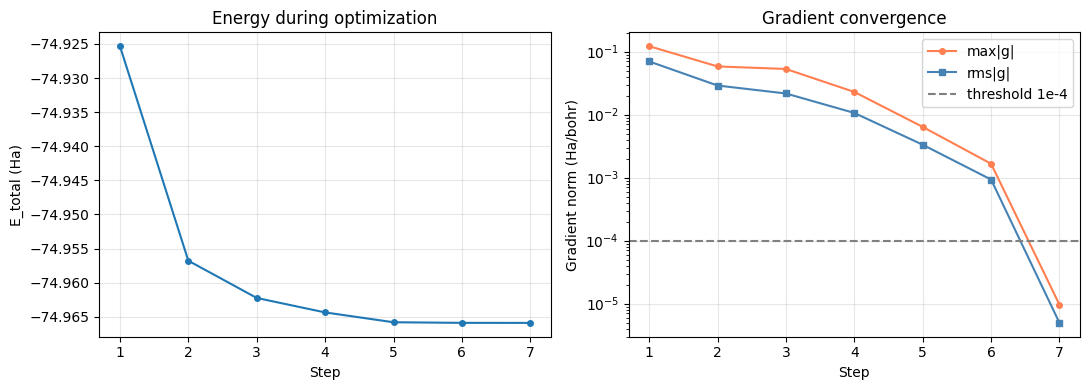

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

steps = range(1, len(opt.energy_history) + 1)
ax1.plot(steps, opt.energy_history, "o-", ms=4)
ax1.set_xlabel("Step")
ax1.set_ylabel("E_total (Ha)")
ax1.set_title("Energy during optimization")
ax1.grid(True, alpha=0.3)

ax2.semilogy(steps, opt.grad_max_history, "o-", ms=4, color="coral", label="max|g|")
ax2.semilogy(steps, opt.grad_rms_history, "s-", ms=4, color="steelblue", label="rms|g|")
ax2.axhline(1e-4, ls="--", color="gray", label="threshold 1e-4")
ax2.set_xlabel("Step")
ax2.set_ylabel("Gradient norm (Ha/bohr)")
ax2.set_title("Gradient convergence")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Extracting bond lengths and angles

From the optimized Cartesian coordinates we can compute the internal coordinates:
bond lengths, angles, and dihedrals.

In [7]:
def bond_length_angstrom(mol, i, j):
    """Bond length between atoms i and j in Angstrom."""
    r = np.linalg.norm(mol.atoms[i].coords - mol.atoms[j].coords)
    return r * BOHR_TO_ANGSTROM

def bond_angle_deg(mol, i, j, k):
    """Angle i-j-k (j is the central atom) in degrees."""
    v1 = mol.atoms[i].coords - mol.atoms[j].coords
    v2 = mol.atoms[k].coords - mol.atoms[j].coords
    cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cos_a, -1, 1)))

opt_mol = opt.final_molecule
r_OH1 = bond_length_angstrom(opt_mol, 0, 1)  # O-H1
r_OH2 = bond_length_angstrom(opt_mol, 0, 2)  # O-H2
angle  = bond_angle_deg(opt_mol, 1, 0, 2)    # H-O-H

print("H₂O/STO-3G optimized geometry:")
print(f"  r(O-H1) = {r_OH1:.4f} Å   (exp. 0.958 Å)")
print(f"  r(O-H2) = {r_OH2:.4f} Å")
print(f"  ∠H-O-H  = {angle:.2f}°     (exp. 104.5°)")

H₂O/STO-3G optimized geometry:
  r(O-H1) = 0.9894 Å   (exp. 0.958 Å)
  r(O-H2) = 0.9894 Å
  ∠H-O-H  = 100.02°     (exp. 104.5°)


## 6. Basis set effect on geometry

STO-3G is known to give reasonable but not accurate geometries.
Let us compare with 6-31G* for H₂O.

In [8]:
for name, basis in [("STO-3G", STO3G), ("6-31G*", G631Star)]:
    opt_r = optimize_geometry(h2o_distorted, basis, verbose=False)
    mol   = opt_r.final_molecule
    r_OH  = bond_length_angstrom(mol, 0, 1)
    ang   = bond_angle_deg(mol, 1, 0, 2)
    print(f"{name:8s}: r(O-H) = {r_OH:.4f} Å,  ∠HOH = {ang:.2f}°,  E = {opt_r.energy_final:.6f} Ha")

print("Experimental:   r(O-H) = 0.9572 Å,  ∠HOH = 104.52°")

STO-3G  : r(O-H) = 0.9894 Å,  ∠HOH = 100.02°,  E = -74.965901 Ha


6-31G*  : r(O-H) = 0.9474 Å,  ∠HOH = 105.48°,  E = -76.010746 Ha
Experimental:   r(O-H) = 0.9572 Å,  ∠HOH = 104.52°


---

## Exercises

**1.** Scan the H₂ PES from 0.4 to 3.0 Å and find the minimum by parabolic interpolation
of the three lowest-energy points. Compare to the gradient-based optimizer result.

**2.** Optimize the geometry of N₂ in STO-3G starting from R = 1.5 Å.
What is the optimized bond length? Compare to the experimental value of 1.098 Å.
Why does STO-3G overestimate or underestimate?

**3.** The gradient of a linear molecule like CO₂ should have zero x and y components
for all atoms (by symmetry). Verify this numerically at the linear geometry.

**4.** What happens if you try to optimize a molecule that is already at its minimum
(use the experimental geometry of H₂)? How many steps does it take?

**5.** (Advanced) Central finite differences have error $\mathcal{O}(h^2)$. Verify this
empirically for H₂ by computing the gradient at R = 0.74 Å for
$h \in \{10^{-1}, 10^{-2}, 10^{-3}, 10^{-4}\}$ and plotting the error vs. $h^2$.

---

## Summary

| Concept | Key point |
|---------|----------|
| Born-Oppenheimer PES | $E(\mathbf{R})$ — total energy as function of nuclear positions |
| Equilibrium geometry | Global/local minimum of PES; $\nabla E = 0$, Hessian positive definite |
| Numerical gradient | Central FD: $(2 \times 3N)$ SCF evaluations per step |
| BFGS | Quasi-Newton; builds approximate inverse Hessian from gradient history |
| Convergence | max$|g| < 10^{-4}$ Ha/bohr |
| Basis effect | Larger basis → better geometry; STO-3G gives useful but imprecise structures |

The equilibrium geometry is necessary for meaningful harmonic frequency calculations —
the subject of Notebook 07.